# 하이퍼 파라미터 튜닝
- 하이퍼 파라미터는 머신 러닝을 구성하는 주요 구성요소
- 이 값을 조정하여 머신러닝 알고리즘의 성능을 개선할 수 있음

## GridSearchCV
- 분류나 회귀 알고리즘에 적용되는 하이퍼 파라미터를 순차적으로 테스트하여 최적의 파라미터를 찾음
- Gird(격자) - 촘촘하게 파라미터를 변화시켜 가면서 테스트해본다는 의미
- GridSerchCV에서 마지막에 'CV'가 붙은 것은 교차검증(cross validation)도 동시에 수행한다는 의미

## 1. 라이브러리/모듈 import

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split 
import pandas as pd

## 2. 붓꽃 데이터셋 로드, 분리(split)

In [2]:
iris = pd.read_csv('iris.csv')
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:
X=iris.iloc[:, :4]
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
y=iris.iloc[:,4]
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

## 3. estimator -결정트리 모델 선택

In [4]:
dtree = DecisionTreeClassifier(random_state=0)

- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

## 4. 하이퍼 파라미터 설정
- 총 6 가지 조합
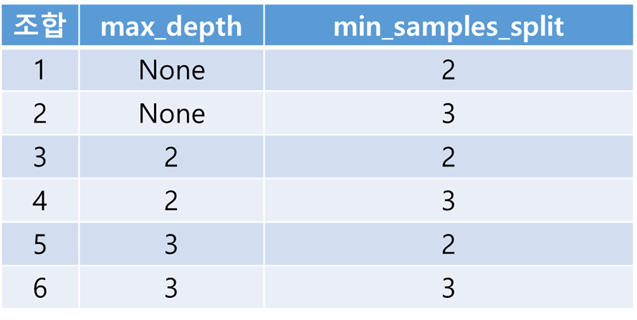

### parameter 들을 dictionary 형태로 설정

In [7]:
parameters = {'max_depth':[None,1,2], 
              'min_samples_split':[2,3]}

## 5. GridSearchCV를 이용하여 3회의 교차검증 실행
- 6세트의 파라미터 조합에 대해 각각 3회씩 실시하므로
    - 총 18회의 학습/평가 수행
------------------------------------
- [parameters]
- estimator 
- parameters: 파라미터 후보군
- cv : 교차검증 횟수 
- scoring : 성능평가함수
- refit=True(default)
    - (최적의 하이퍼 파라미터로 재학습 시켜 best_estimator_로 저장)

In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:
grid_dtree = GridSearchCV(dtree, parameters, cv=3, scoring='accuracy')  

* **붓꽃 Train 데이터로 param_grid의 하이퍼 파라미터들을 순차적으로 학습/평가**

In [10]:
grid_dtree.fit(X, y)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [None, 1, 2],
                         'min_samples_split': [2, 3]},
             scoring='accuracy')

## 6. 최적의 하이퍼 파라미터 확인(3,2)

* **GridSearchCV 결과 추출하여 DataFrame으로 변환**

In [11]:
grid_dtree.cv_results_

{'mean_fit_time': array([0.00268126, 0.0009973 , 0.00132974, 0.0009977 , 0.00099699,
        0.00166233]),
 'std_fit_time': array([9.45216724e-04, 3.89335909e-07, 4.69965469e-04, 5.94720425e-07,
        4.05233662e-07, 4.70415035e-04]),
 'mean_score_time': array([0.0013086 , 0.00099715, 0.0009973 , 0.00099746, 0.00099723,
        0.00132998]),
 'std_score_time': array([4.65436560e-04, 2.24783192e-07, 1.94667955e-07, 4.49566384e-07,
        4.05233662e-07, 4.70134086e-04]),
 'param_max_depth': masked_array(data=[None, None, 1, 1, 2, 2],
              mask=[False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_min_samples_split': masked_array(data=[2, 3, 2, 3, 2, 3],
              mask=[False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'max_depth': None, 'min_samples_split': 2},
  {'max_depth': None, 'min_samples_split': 3},
  {'max_depth': 1, 'min_samples_split': 2},
  {'max_depth'

In [62]:
scores_df = pd.DataFrame(grid_dtree.cv_results_)

In [63]:
scores_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000665,0.000470,0.000333,0.00047,None,2,"{'max_depth': None, 'min_samples_split': 2}",0.98,0.94,0.98,0.966667,0.018856,2
1,0.000333,0.000471,0.000333,0.00047,None,3,"{'max_depth': None, 'min_samples_split': 3}",0.98,0.94,1.00,0.973333,0.024944,1
2,0.001330,0.000470,0.000665,0.00047,1,2,"{'max_depth': 1, 'min_samples_split': 2}",0.66,0.66,0.66,0.660000,0.000000,5
3,0.000997,0.000815,0.000332,0.00047,1,3,"{'max_depth': 1, 'min_samples_split': 3}",0.66,0.66,0.66,0.660000,0.000000,5
4,0.000665,0.000470,0.000332,0.00047,2,2,"{'max_depth': 2, 'min_samples_split': 2}",0.96,0.92,0.92,0.933333,0.018856,3
5,0.000665,0.000470,0.000000,0.00000,2,3,"{'max_depth': 2, 'min_samples_split': 3}",0.96,0.92,0.92,0.933333,0.018856,3


In [64]:
scores_df[['params', 'mean_test_score', 'rank_test_score',
           'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': None, 'min_samples_split': 2}",0.966667,2,0.98,0.94,0.98
1,"{'max_depth': None, 'min_samples_split': 3}",0.973333,1,0.98,0.94,1.00
2,"{'max_depth': 1, 'min_samples_split': 2}",0.660000,5,0.66,0.66,0.66
3,"{'max_depth': 1, 'min_samples_split': 3}",0.660000,5,0.66,0.66,0.66
4,"{'max_depth': 2, 'min_samples_split': 2}",0.933333,3,0.96,0.92,0.92
5,"{'max_depth': 2, 'min_samples_split': 3}",0.933333,3,0.96,0.92,0.92


In [65]:
# drop을 써서 표현하면??
scores_df.drop(['std_fit_time','mean_fit_time','std_score_time','mean_score_time','param_max_depth','param_min_samples_split'], axis=1)

,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': None, 'min_samples_split': 2}",0.98,0.94,0.98,0.966667,0.018856,2
1,"{'max_depth': None, 'min_samples_split': 3}",0.98,0.94,1.00,0.973333,0.024944,1
2,"{'max_depth': 1, 'min_samples_split': 2}",0.66,0.66,0.66,0.660000,0.000000,5
3,"{'max_depth': 1, 'min_samples_split': 3}",0.66,0.66,0.66,0.660000,0.000000,5
4,"{'max_depth': 2, 'min_samples_split': 2}",0.96,0.92,0.92,0.933333,0.018856,3
5,"{'max_depth': 2, 'min_samples_split': 3}",0.96,0.92,0.92,0.933333,0.018856,3


## 7. 최적의 하이퍼 파라미터에서 성능 확인

In [66]:
# 최적 파라미터
grid_dtree.best_params_

{'max_depth': None, 'min_samples_split': 3}

In [67]:
# 최적 파라미터에서의 accuracy: GridSearchCV()에서 자체적으로 수행한 검증 평균값
grid_dtree.best_score_

0.9733333333333333

* **best_estimator_ : GridSearchCV의 refit으로 이미 학습이 된 estimator**

In [68]:
grid_dtree.best_estimator_

DecisionTreeClassifier(min_samples_split=3, random_state=0)

In [69]:
# best_estimator의 depth인 None의  실제값 확인

grid_dtree.best_estimator_.get_depth()

5

## 8. Hyper Parameter추가 하여 GridSearchCV를 해보자. best parameter는 바뀌는가?
- parameters = {'max_depth':[None,2,3,4], 'min_samples_split':[2,3,4,5]}

## 9. 회귀모델에서의 scoring
- GridSearchCV는 score값이 클수록 우수한 파라미터라고 판단함
- 하지만 회귀모델의 Error지표는 score값이 작을수록 우수한 파라미터임
- 따라서 회귀모델에서는 scoring함수를 negative함수로 활용함
    - https://scikit-learn.org/stable/modules/model_evaluation.html

## 10. 사용자 정의 함수로 scoring
- bike예제의 rmsle처럼 사용자 정의 함수를 사용할 경우 다음과 같이 make_scorer()함수를 활용한다.
    - scoring=**make_scorer(사용자정의 함수명, greater_is_better=True(default))**
        - 회귀모델의 error지표라면 **greater_is_better=False**

    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html#sklearn.metrics.make_scorer